Installation

In [14]:
%pip install "pandas<3.0.0" "google-genai" "python-dotenv" "openai" "scikit-learn" "seaborn" -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 43.5 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 55.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 60.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m7/8 [seaborn]ib]

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Loading GEMINI API KEY

In [2]:
from google import genai
import os
from dotenv import load_dotenv
# loading variables from .env file
load_dotenv() 

API_KEY = os.getenv('GEMINI_API_KEY')
client = genai.Client(api_key=API_KEY)

In [5]:
from openai import OpenAI
import os
from dotenv import load_dotenv
# loading variables from .env file
load_dotenv() 

# It will look for an environment variable named OPENAI_API_KEY
client = OpenAI()

In [1]:
import anthropic
import os
from dotenv import load_dotenv
# loading variables from .env file
load_dotenv() 

# Best practice: Set your API key in your environment variables
# os.environ["ANTHROPIC_API_KEY"] = "your-api-key-here"

client_claude = anthropic.Anthropic(
    api_key=os.getenv("ANTHROPIC_API_KEY"),
)

###**Bio Generation**

get speaker bio

In [7]:
import random
import time
from tqdm.auto import tqdm

def generate_global_bios(df):
    """Creates a dictionary of character summaries to give Gemini personality context."""
    bios = {}
    # We take a few sample lines for each speaker to 'prime' the model
    for speaker in df['Speaker'].unique():
        speaker_data = df[df['Speaker'] == speaker]['Utterance']
        
        sample_size = min(len(speaker_data), 10) 
        
        samples = speaker_data.sample(sample_size).tolist()
        samples_str = " ".join([f'"{s}"' for s in samples])
        bios[speaker] = f"{speaker} typically speaks like this: {samples_str}"
    return bios

DIALOGUE BASED CONTEXT WINDOW

In [ ]:
#Gemini, Chatgpt

def predict_dialogue_emotions(bios, dialogue_group):
    """Sends an entire dialogue to Gemini 2.5 and gets a list of emotions back."""
    # Ensure labels are alphabetical as per your preference
    valid_labels = ["Anger", "Disgust", "Fear", "Joy", "Neutral", "Sadness", "Surprise"]
    
    # Format the dialogue turns for the prompt
    turns = [f"Turn {i+1} - {r['Speaker']}: {r['Utterance']}" for i, r in enumerate(dialogue_group)]
    dialogue_text = "\n".join(turns)
    
    # Filter bios to only those present in this specific dialogue
    relevant_bios = "\n".join([bios.get(s, "") for s in set(r['Speaker'] for r in dialogue_group)])

    prompt = f"""Task: Assign exactly one emotion label to EACH turn in the dialogue below.
    Return a JSON object with the key "predictions" containing a list of strings.
    The length of the list must be exactly {len(dialogue_group)}.

    SPEAKER CONTEXT:
    {relevant_bios}

    DIALOGUE TO ANALYZE:
    {dialogue_text}

    ALLOWED LABELS (Alphabetical): {valid_labels}

    Output Format: {{"predictions": ["Label1", "Label2", ...]}}"""

    # Using Gemini 2.5 Flash for speed and long-context reasoning
    # response = client.models.generate_content(
    #     model="gemini-2.5-flash",
    #     contents=prompt,
    #     config={'response_mime_type': 'application/json'}
    # )
    # # response = client.chat.completions.create(
    #     model="gpt-5.2", # Use gpt-4o if you want to save credits
    #     messages=[
    #         {"role": "user", "content": prompt}
    #     ],
    #     response_format={"type": "json_object"}
    # )
    
    # Parse the JSON response
    try:
        import json
        # predictions = json.loads(response.text)
        # # Basic validation: ensure it's a list and matches length
        # if not isinstance(predictions, list) or len(predictions) != len(dialogue_group):
        #     return ["Neutral"] * len(dialogue_group)
        # return [p if p in valid_labels else "Neutral" for p in predictions]
        response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt,
        config={'response_mime_type': 'application/json'}
        )
        raw_content = response.text
        data = json.loads(raw_content)
        
        if isinstance(data, dict) and "predictions" in data:
            predictions = data["predictions"]
        elif isinstance(data, dict) and "emotions" in data: 
            predictions = data["emotions"]
        else:
            predictions = data

        if not isinstance(predictions, list) or len(predictions) != len(dialogue_group):
            return ["Neutral"] * len(dialogue_group)
            
        return [p if p in valid_labels else "Neutral" for p in predictions]
        
        # #chat gpt
        # raw_content = response.choices[0].message.content
        
        # # If GPT-5.2 returns {"emotions": [...]}, you'll need to grab the key.
        # # If it returns a raw list string "[...]", json.loads handles it.
        # data = json.loads(raw_content)
        
        # if isinstance(data, dict) and "predictions" in data:
        #     predictions = data["predictions"]
        # elif isinstance(data, dict) and "emotions" in data: # Backup check
        #     predictions = data["emotions"]
        # else:
        #     predictions = data

        # if not isinstance(predictions, list) or len(predictions) != len(dialogue_group):
        #     return ["Neutral"] * len(dialogue_group)
            
    #     # return [p if p in valid_labels else "Neutral" for p in predictions]
    except Exception as e:
        print(f"Parsing error: {e}")
        return ["Neutral"] * len(dialogue_group)

In [8]:
# CLAUDE
import os
def predict_dialogue_emotions2(bios, dialogue_group):
    import json
    import re # Added for cleaning the response
    valid_labels = ["Anger", "Disgust", "Fear", "Joy", "Neutral", "Sadness", "Surprise"]
    
    turns = [f"Turn {i+1} - {r['Speaker']}: {r['Utterance']}" for i, r in enumerate(dialogue_group)]
    dialogue_text = "\n".join(turns)
    relevant_bios = "\n".join([bios.get(s, "") for s in set(r['Speaker'] for r in dialogue_group)])

    system_prompt = f"""You are an expert emotion classifier. 
Assign exactly one emotion label to EACH turn in the dialogue.
ALLOWED LABELS (Alphabetical): {valid_labels}

Output Format: You MUST return a JSON object with the key "predictions" containing a list of strings."""

    user_prompt = f"""SPEAKER CONTEXT:
{relevant_bios}

DIALOGUE TO ANALYZE:
{dialogue_text}

The length of the 'predictions' list must be exactly {len(dialogue_group)}."""

    try:
        # Using the current 2026 stable model ID
        response = client_claude.messages.create(
            model="claude-sonnet-4-6", 
            max_tokens=2048,
            system=system_prompt,
            messages=[
                {"role": "user", "content": user_prompt}
            ]
        )

        raw_content = response.content[0].text
        
        # --- CLEANING LOGIC ---
        # 1. Strip whitespace
        raw_content = raw_content.strip()
        
        # 2. Use Regex to find the JSON block if Claude wrapped it in ```json
        # This prevents the "char 0" parsing error
        json_match = re.search(r'\{.*\}', raw_content, re.DOTALL)
        if json_match:
            raw_content = json_match.group(0)
        
        data = json.loads(raw_content)
        
        # Handle different potential key names
        predictions = data.get("predictions", data.get("emotions", data))

        if not isinstance(predictions, list) or len(predictions) != len(dialogue_group):
            return ["Neutral"] * len(dialogue_group)
            
        return [p if p in valid_labels else "Neutral" for p in predictions]

    except Exception as e:
        print(f"Claude API/Parsing error: {e}")
        # If it's a JSON error, printing the first 100 chars of raw_content helps debug
        return ["Neutral"] * len(dialogue_group)

processing data

In [ ]:
import pandas as pd
#per speaker per dialogue
def process_meld_batch(file_path, output_csv="hierarchical_results.csv"):
    df = pd.read_csv(file_path)
    df = df.sort_values(['Dialogue_ID', 'Utterance_ID'])

    processed_ids = set()
    if os.path.exists(output_csv):
        existing_df = pd.read_csv(output_csv)
        if not existing_df.empty:
            processed_ids = set(existing_df['Dialogue_ID'].unique())
            print(f"Skipping {len(processed_ids)} already processed dialogues.")
    
    bios = generate_global_bios(df)
    results = []
    grouped = df.groupby('Dialogue_ID')

    for diag_id, group in tqdm(grouped, desc="Processing Dialogues"):
        if diag_id in processed_ids:
            continue
        group_list = group.to_dict('records')
        try:
            predictions = predict_dialogue_emotions2(bios, group_list)
            
            curr_batch = []
            for i, row in enumerate(group_list):
                curr_batch.append({
                    'Dialogue_ID': diag_id,
                    'Utterance_ID': row['Utterance_ID'],
                    'Speaker': row['Speaker'],
                    'Original_Emotion': row['Emotion'],
                    'Predicted_Emotion': predictions[i] if i < len(predictions) else "Neutral"
                })
            
            new_df = pd.DataFrame(curr_batch)
            if not os.path.isfile(output_csv):
                new_df.to_csv(output_csv, index=False)
            else:
                new_df.to_csv(output_csv, mode='a', header=False, index=False)
            results.extend(curr_batch)
        except Exception as e:
            if "429" in str(e):
                print("\nQuota hit! Saving and exiting...")
                pd.DataFrame(results).to_csv(output_csv, index=False)
                return  # Exit gracefully so you can restart later
            print(f"Error at {diag_id}: {e}")

    return pd.DataFrame(results)

# Run it!
final_df = process_meld_batch(r"/home/liaojd/SenticCrystal/data/meld_7way_data/train_sent_emo.csv", "results_claude3.csv")

Processing Dialogues: 100%|██████████| 1038/1038 [46:24<00:00,  2.68s/it] 


In [ ]:
import os
import pandas as pd
from tqdm import tqdm

# PER SPEAKER

def process_meld_batch(file_path, output_csv="results_claude3_per_speaker.csv"):
    df = pd.read_csv(file_path)
    # Sort by Dialogue and Utterance just to keep an internal order track
    df = df.sort_values(['Dialogue_ID', 'Utterance_ID'])

    # --- 1. RESUME CHECK ---
    # Since we are writing out by Speaker groups now, we track completed unique rows
    processed_keys = set()
    if os.path.exists(output_csv):
        try:
            existing_df = pd.read_csv(output_csv)
            if not existing_df.empty:
                # Create a unique tracking key for each row: "DialogueID_UtteranceID"
                processed_keys = set(existing_df['Dialogue_ID'].astype(str) + "_" + existing_df['Utterance_ID'].astype(str))
                print(f"Skipping {len(processed_keys)} already processed utterances.")
        except Exception:
            print("Output file found but empty. Starting fresh.")
    
    # Generate the global bios across the entire dataset
    bios = generate_global_bios(df)
    results = []
    # switch to per speaker
    grouped_by_speaker = df.groupby('Speaker')

    for speaker_name, speaker_group in tqdm(grouped_by_speaker, desc="Processing Per-Speaker Batches"):
        # Filter out rows we already completed in a past run
        speaker_group['row_key'] = speaker_group['Dialogue_ID'].astype(str) + "_" + speaker_group['Utterance_ID'].astype(str)
        unprocessed_group = speaker_group[~speaker_group['row_key'].isin(processed_keys)]
        
        if unprocessed_group.empty:
            continue
            
        # Convert to records
        all_lines = unprocessed_group.to_dict('records')
        
        # We chunk the speaker's lines into batches (e.g., 15 lines at a time) 
        # so we don't blow past Claude's output limit or make the prompt unreadable.
        chunk_size = 15 
        for chunk_idx in range(0, len(all_lines), chunk_size):
            chunk = all_lines[chunk_idx:chunk_idx + chunk_size]
            
            try:
                # Pass the chunk to your prediction function
                predictions = predict_dialogue_emotions2(bios, chunk)
                
                curr_batch = []
                for i, row in enumerate(chunk):
                    curr_batch.append({
                        'Dialogue_ID': row['Dialogue_ID'],
                        'Utterance_ID': row['Utterance_ID'],
                        'Speaker': row['Speaker'],
                        'Original_Emotion': row['Emotion'],
                        'Predicted_Emotion': predictions[i] if i < len(predictions) else "Neutral"
                    })
                
                # Append immediately to file
                new_df = pd.DataFrame(curr_batch)
                if not os.path.isfile(output_csv):
                    new_df.to_csv(output_csv, index=False)
                else:
                    new_df.to_csv(output_csv, mode='a', header=False, index=False)
                results.extend(curr_batch)
                
            except Exception as e:
                if "429" in str(e) or "Overloaded" in str(e):
                    print(f"\nQuota/Rate limit hit at speaker {speaker_name}! Stopping gracefully.")
                    return pd.DataFrame(results)
                print(f"Error processing chunk for {speaker_name}: {e}")

    return pd.DataFrame(results)
final_df = process_meld_batch(r"/home/liaojd/SenticCrystal/data/meld_7way_data/train_sent_emo.csv", "results_claude1_per_speaker.csv")

Processing Per-Speaker Batches:  42%|████▏     | 108/260 [08:23<05:40,  2.24s/it] 

Claude API/Parsing error: Extra data: line 20 column 1 (char 242)


Processing Per-Speaker Batches: 100%|██████████| 260/260 [38:21<00:00,  8.85s/it]   


--- Classification Report ---
              precision    recall  f1-score   support

       anger       0.55      0.55      0.55      1109
     disgust       0.30      0.36      0.33       271
        fear       0.27      0.52      0.36       268
         joy       0.57      0.65      0.61      1743
     neutral       0.80      0.70      0.75      4710
     sadness       0.50      0.41      0.45       683
    surprise       0.55      0.63      0.59      1205

    accuracy                           0.63      9989
   macro avg       0.51      0.55      0.52      9989
weighted avg       0.65      0.63      0.64      9989

Overall Weighted F1 Score: 0.6393


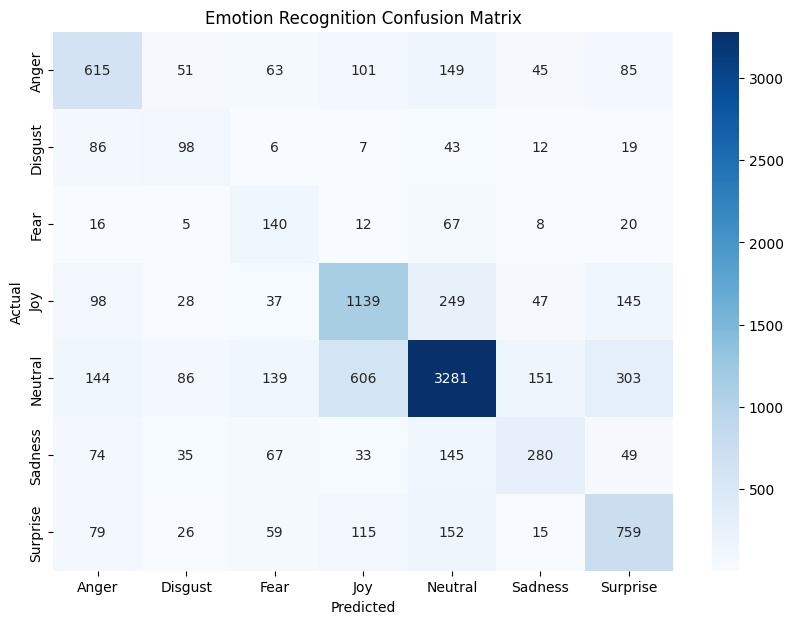

In [10]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_results(csv_file):
    df = pd.read_csv(csv_file)
    df['Predicted_Emotion'] = df['Predicted_Emotion'].astype(str).str.strip().str.lower()
    df['Original_Emotion'] = df['Original_Emotion'].astype(str).str.strip().str.lower()
    labels = ["anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"]

    print("--- Classification Report ---")
    # Adding zero_division=0 hides the warnings for missing labels
    print(classification_report(df['Original_Emotion'], 
                                df['Predicted_Emotion'], 
                                labels=labels,
                                zero_division=0))

    weighted_f1 = f1_score(df['Original_Emotion'], 
                           df['Predicted_Emotion'], 
                           average='weighted')
    print(f"Overall Weighted F1 Score: {weighted_f1:.4f}")
    cm = confusion_matrix(df['Original_Emotion'], 
                          df['Predicted_Emotion'], 
                          labels=labels)
    
    plt.figure(figsize=(10, 7))
    display_labels = [l.capitalize() for l in labels]
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=display_labels, yticklabels=display_labels, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Emotion Recognition Confusion Matrix')
    plt.show()
evaluate_results("results_claude1_per_speaker.csv")

In [6]:
import pandas as pd

# Load your results
file_name = "results_gemini2.csv"
df = pd.read_csv(file_name)

print(f"--- Initial Stats ---")
print(f"Total rows: {len(df)}")

# 1. Identify and Drop Duplicates
# We use Dialogue_ID and Utterance_ID because that pair is the unique 'primary key' for MELD
df_cleaned = df.drop_duplicates(subset=['Dialogue_ID', 'Utterance_ID'], keep='first')

print(f"\n--- Cleaning Results ---")
print(f"Rows removed: {len(df) - len(df_cleaned)}")
print(f"Final unique rows: {len(df_cleaned)}")

# 2. Safety Check: Verify the Support number
# If your goal was the Train set, this should be exactly 9989
if len(df_cleaned) == 9989:
    print("✅ SUCCESS: Your support count matches the MELD Training set.")
elif len(df_cleaned) < 9989:
    print(f"⚠️ WARNING: You are missing {9989 - len(df_cleaned)} utterances. Did the script finish?")
else:
    print(f"❓ NOTE: You still have {len(df_cleaned)} rows. You might have merged Train + Dev.")

# 3. Save the clean file
output_name = "results_gemini2_final.csv"
df_cleaned.to_csv(output_name, index=False)
print(f"\nCleaned file saved as: {output_name}")

--- Initial Stats ---
Total rows: 16506

--- Cleaning Results ---
Rows removed: 6517
Final unique rows: 9989
✅ SUCCESS: Your support count matches the MELD Training set.

Cleaned file saved as: results_gemini2_final.csv


STOP HERE?


In [ ]:
def predict_dialogue_emotions_sliding(bios, dialogue_group, window_size=3):
    """
    Predicts emotions turn-by-turn using a sliding window.
    window_size=0: No previous context (just the current line)
    window_size=3: Current line + 3 previous lines
    """
    import json
    predictions = []
    valid_labels = ["Anger", "Disgust", "Fear", "Joy", "Neutral", "Sadness", "Surprise"]

    for i in range(len(dialogue_group)):
        # 1. Define the window: from (current - window_size) up to current
        start_idx = max(0, i - window_size)
        context_turns = dialogue_group[start_idx : i + 1] # Includes the current turn
        
        # 2. Format the turns for the prompt
        # We label them clearly so the AI knows which one is the "Target"
        formatted_context = []
        for j, r in enumerate(context_turns):
            prefix = "CONTEXT" if j < (len(context_turns) - 1) else "TARGET (Predict this)"
            formatted_context.append(f"{prefix} - {r['Speaker']}: {r['Utterance']}")
        
        context_text = "\n".join(formatted_context)
        
        # 3. Get bios for speakers in this specific window
        current_speakers = set(r['Speaker'] for r in context_turns)
        relevant_bios = "\n".join([bios.get(s, "") for s in current_speakers])

        prompt = f"""Task: Assign exactly one emotion label to the TARGET turn.
Use the provided CONTEXT turns to understand the emotional flow.

SPEAKER CONTEXT:
{relevant_bios}

DIALOGUE WINDOW:
{context_text}

ALLOWED LABELS: {valid_labels}
Return ONLY a JSON string containing the label, e.g., "Neutral"."""

        # 4. API Call per turn
        try:
            response = client.models.generate_content(
                model="gemini-2.5-flash",
                contents=prompt,
                config={'response_mime_type': 'application/json'}
            )
            label = json.loads(response.text)
            predictions.append(label if label in valid_labels else "Neutral")
        except:
            predictions.append("Neutral")

    return predictions

In [ ]:
def predict_dialogue_emotions_window(bios, dialogue_group):
    """Sends an entire dialogue to Gemini 2.5 and gets a list of emotions back."""
    # Ensure labels are alphabetical as per your preference
    valid_labels = ["Anger", "Disgust", "Fear", "Joy", "Neutral", "Sadness", "Surprise"]
    
    # Format the dialogue turns for the prompt
    turns = [f"Turn {i+1} - {r['Speaker']}: {r['Utterance']}" for i, r in enumerate(dialogue_group)]
    dialogue_text = "\n".join(turns)
    
    # Filter bios to only those present in this specific dialogue
    relevant_bios = "\n".join([bios.get(s, "") for s in set(r['Speaker'] for r in dialogue_group)])
    window_size = 3
    prompt = f"""Task: Assign exactly one emotion label to EACH turn in the dialogue below.
Return a JSON list of strings of length {len(dialogue_group)}.

CRITICAL RULE for Window Size {window_size}:
When deciding the emotion for "Turn N", you must ONLY consider the text in "Turn N" and the 
{window_size} turns immediately preceding it. 
DO NOT use information from any turns that come AFTER "Turn N". 

SPEAKER CONTEXT:
{relevant_bios}

DIALOGUE TO ANALYZE:
{dialogue_text}

ALLOWED LABELS: {valid_labels}
Output Format: ["Label1", "Label2", ...]"""
    # Using Gemini 2.5 Flash for speed and long-context reasoning
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt,
        config={'response_mime_type': 'application/json'}
    )
    
    # Parse the JSON response
    try:
        import json
        predictions = json.loads(response.text)
        # Basic validation: ensure it's a list and matches length
        if not isinstance(predictions, list) or len(predictions) != len(dialogue_group):
            return ["Neutral"] * len(dialogue_group)
        return [p if p in valid_labels else "Neutral" for p in predictions]
    except:
        return ["Neutral"] * len(dialogue_group)